In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import gaussian_filter
import numpy as np
import os
from scipy.optimize import curve_fit
from copy import deepcopy
import h5py

In [ ]:
def find_angle_ellipse(path_img):
    """ Return the angle at which the mean along the horizontal axis is maximal """
    theta_range = np.arange(0, 180, 1e0)

    img = Image.open(path_img)

    Max_horizontal = np.zeros(len(theta_range))

    for (i, theta) in enumerate(theta_range):
        Max_horizontal[i] = max(np.mean(np.array(img.rotate(theta)), axis=1))

    return theta_range[np.argmax(Max_horizontal)]

def find_center(img):
    """ Return the center of the beam after smoothing the image (nparray).
    First value returned = x0 = column
    Second value returned = y0 = line """
    img_smooth = gaussian_filter(img, sigma=10)
    return np.argmax(np.mean(img_smooth, axis=0)), np.argmax(np.mean(img_smooth, axis=1))


def fit_img_rotated(path_img):
    """ Fit the elliptic shape of a beam with 2 gaussians and return their waists 
     after rotating the image so that the major axis of this beam shape is along the horizontal axis """
    theta = find_angle_ellipse(path_img)
    img = np.array(Image.open(path_img).rotate(theta))

    x0, y0 = find_center(img)
    Horizontal_fit = curve_fit(lambda r, w : gaussian(r, img[y0, x0], w, x0, np.mean(img[-20:-10, -20:-10])), np.arange(len(img[y0, :])), img[y0, :])[0][0]
    Vertical_fit = curve_fit(lambda r, w : gaussian(r, img[y0, x0], w, y0, np.mean(img[-20:-10, -20:-10])), np.arange(len(img[:, x0])), img[:, x0])[0][0]
    return [Horizontal_fit, Vertical_fit]

def fit_img_rotated_far_theta(path_img, theta):
    """ Fit the elliptic shape of a beam with 2 gaussians and return their waists 
     after rotating the image  by an angle theta (usually the angl of the far images) """
    img = np.array(Image.open(path_img).rotate(theta))
    x0, y0 = find_center(img)
    Horizontal_fit = curve_fit(lambda r, w : gaussian(r, img[y0, x0], w, x0, np.mean(img[-20:-10, -20:-10])), np.arange(len(img[y0, :])), img[y0, :])[0][0]
    Vertical_fit = curve_fit(lambda r, w : gaussian(r, img[y0, x0], w, y0, np.mean(img[-20:-10, -20:-10])), np.arange(len(img[:, x0])), img[:, x0])[0][0]
    return [Horizontal_fit, Vertical_fit]

def gaussian(r, I0, w, mu, bkg):
    """ Gaussian to fit the beam shapes """
    return I0*np.exp(-2*(r-mu)**2/w**2)+bkg

def check_fits(path_img, theta, waists, Size_pxl):
    """ For each image, rotate them by the angle theta, find the center of the gaussian 
    and plot the major minor axis and the corresponding fits """
    if not(os.path.isdir("Check_fits")):
        os.mkdir("Check_fits")
    img = np.array(Image.open(path_img).rotate(theta))

    x0, y0 = find_center(img)
    Major_axis, Minor_axis = img[y0, :], img[:, x0]

    plt.close("all")
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    line1, = axs[1].plot(Major_axis, label="Major axis")
    line2, = axs[1].plot(Minor_axis, label="Minor axis")

    axs[1].plot(gaussian(np.arange(len(img[y0, :])), img[y0, x0], waists[0]/Size_pxl, x0, np.mean(img[len(img[y0, :])//2-10:len(img[y0, :])//2+10, -20:-10])), linestyle="--", color=line1.get_color())
    axs[1].plot(gaussian(np.arange(len(img[:, x0])), img[y0, x0], waists[1]/Size_pxl, y0, np.mean(img[len(img[y0, :])//2-10:len(img[y0, :])//2+10, -20:-10])), linestyle="--", color=line2.get_color())
    axs[1].legend()

    img[:, x0], img[y0, :] = 0, 0
    img[len(img[y0, :])//2-10:len(img[y0, :])//2+10, -20:-10] = 50000
    axs[0].imshow(img)
    fig.savefig("Check_fits/"+os.path.split(path_img)[-1])
    return None

def waist_fit(z, w0, zR, z0):
    """ Fit th waist at z=0 and the Rayleigh length """
    return w0 * np.sqrt(1 + ((z-z0)/zR)**2)

def waist_fit_gaussian(z, w0, z0, lamb):
    """ Fit the waist at z=0 for a gaussian beam """
    return w0 * np.sqrt(1 + lamb**2 * ((z-z0)/(np.pi*(w0**2)))**2)

def waist_fit_M2(z, w0, z0, M2, lamb):
    """ Fit the waist at z=0 for a beam with an M2 value of M """
    return w0 * np.sqrt(1 + M2**2 * (lamb/(np.pi*w0**2))**2 * (z-z0)**2)

In [ ]:
filename = "Y:/StructuralPhaseTransition/2026/02/11/0001/2026-02-11_0001_StructuralPhaseTransition_379.h5"
size_pxl = 0.1966e-6 # New pxl size since 2025/12/31

with h5py.File(filename, "r") as f:
    img_bkg = np.array(f["images/Vertical_Axis_Camera/in_situ_absorption/background"])

### Find center

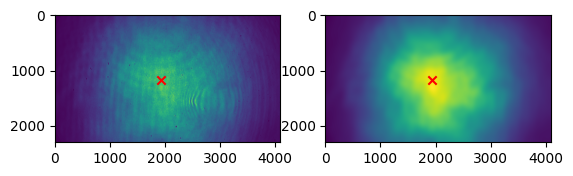

In [ ]:
plt.close("all")

fig, axes = plt.subplots(1, 2)
axes[0].imshow(img_bkg)
img_bkg_smooth = gaussian_filter(img_bkg, sigma=50)
axes[1].imshow(img_bkg_smooth)

center = find_center(img_bkg)

axes[0].scatter(center[0], center[1], marker="x", color="r")
axes[1].scatter(center[0], center[1], marker="x", color="r")

### Find waist

In [ ]:
x0, y0 = center

img_fit = img_bkg

Horizontal_fit = curve_fit(lambda r, w : gaussian(r, img_fit[y0, x0], w, x0, np.mean(img_fit[-20:-10, -20:-10])), np.arange(len(img_fit[y0, :])), img_fit[y0, :])[0][0]
Vertical_fit = curve_fit(lambda r, w : gaussian(r, img_fit[y0, x0], w, y0, np.mean(img_fit[-20:-10, -20:-10])), np.arange(len(img_fit[:, x0])), img_fit[:, x0])[0][0]

In [ ]:
Horizontal_fit * size_pxl * 1e6

np.float64(279.6122308433473)

In [ ]:
Vertical_fit * size_pxl * 1e6

np.float64(267.45091102742725)

In [ ]:
(Horizontal_fit * size_pxl * 1e6 + Vertical_fit * size_pxl * 1e6)/2

np.float64(273.53157093538726)

### Integrate over $\theta$

In [ ]:
theta_range = np.arange(0, 360, 1)

img_mean_rot = np.zeros(np.shape(img_bkg))
for theta in theta_range:
    img_mean_rot += np.array(Image.fromarray(img_bkg).rotate(theta, center=center))


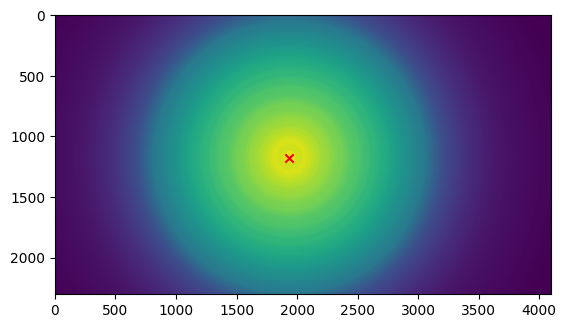

In [ ]:
plt.imshow(img_mean_rot)
plt.scatter(center[0], center[1], marker="x", color="r")

In [ ]:
img_fit = img_mean_rot
curve_fit(lambda r, w : gaussian(r, img_fit[y0, x0], w, x0, np.mean(img_fit[-20:-10, -20:-10])), np.arange(len(img_fit[y0, :])), img_fit[y0, :])[0][0]*size_pxl*1e6

np.float64(300.0750022524122)